In [29]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load datasets
df_cems = pd.read_csv("cleaned_cems.csv")
df_pw = pd.read_csv("cleaned_pollution_weather.csv")

# Overview of datasets
print("CEMS Data Overview:\n", df_cems.info(), "\n")
print("Pollution & Weather Data Overview:\n", df_pw.info(), "\n")

# Check missing values
print("Missing Values in CEMS:\n", df_cems.isnull().sum(), "\n")
print("Missing Values in Pollution & Weather:\n", df_pw.isnull().sum(), "\n")


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 169855 entries, 0 to 169854
Data columns (total 18 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   firm_name      169855 non-null  object 
 1   pollutant_x    169855 non-null  object 
 2   time_x         169855 non-null  float64
 3   concentration  169855 non-null  float64
 4   provorg        169855 non-null  object 
 5   dow            169855 non-null  float64
 6   proven         169855 non-null  object 
 7   date           169855 non-null  object 
 8   time_y         169855 non-null  float64
 9   year_x         169855 non-null  float64
 10  nfirms_x       169855 non-null  float64
 11  pollutant_y    169855 non-null  object 
 12  provid_x       169855 non-null  float64
 13  time           169855 non-null  float64
 14  year_y         169855 non-null  float64
 15  nfirms_y       169855 non-null  float64
 16  pollutant      169855 non-null  object 
 17  provid_y       169855 non-nul

In [30]:
# Histograms of emissions
df_cems[["concentration", "nfirms", "nfirms_so2", "pollution_index"]].hist(figsize=(12,6), bins=30)
plt.suptitle("Distribution of Emissions & Pollution Index", fontsize=14)
plt.show()


KeyError: "['nfirms', 'nfirms_so2', 'pollution_index'] not in index"

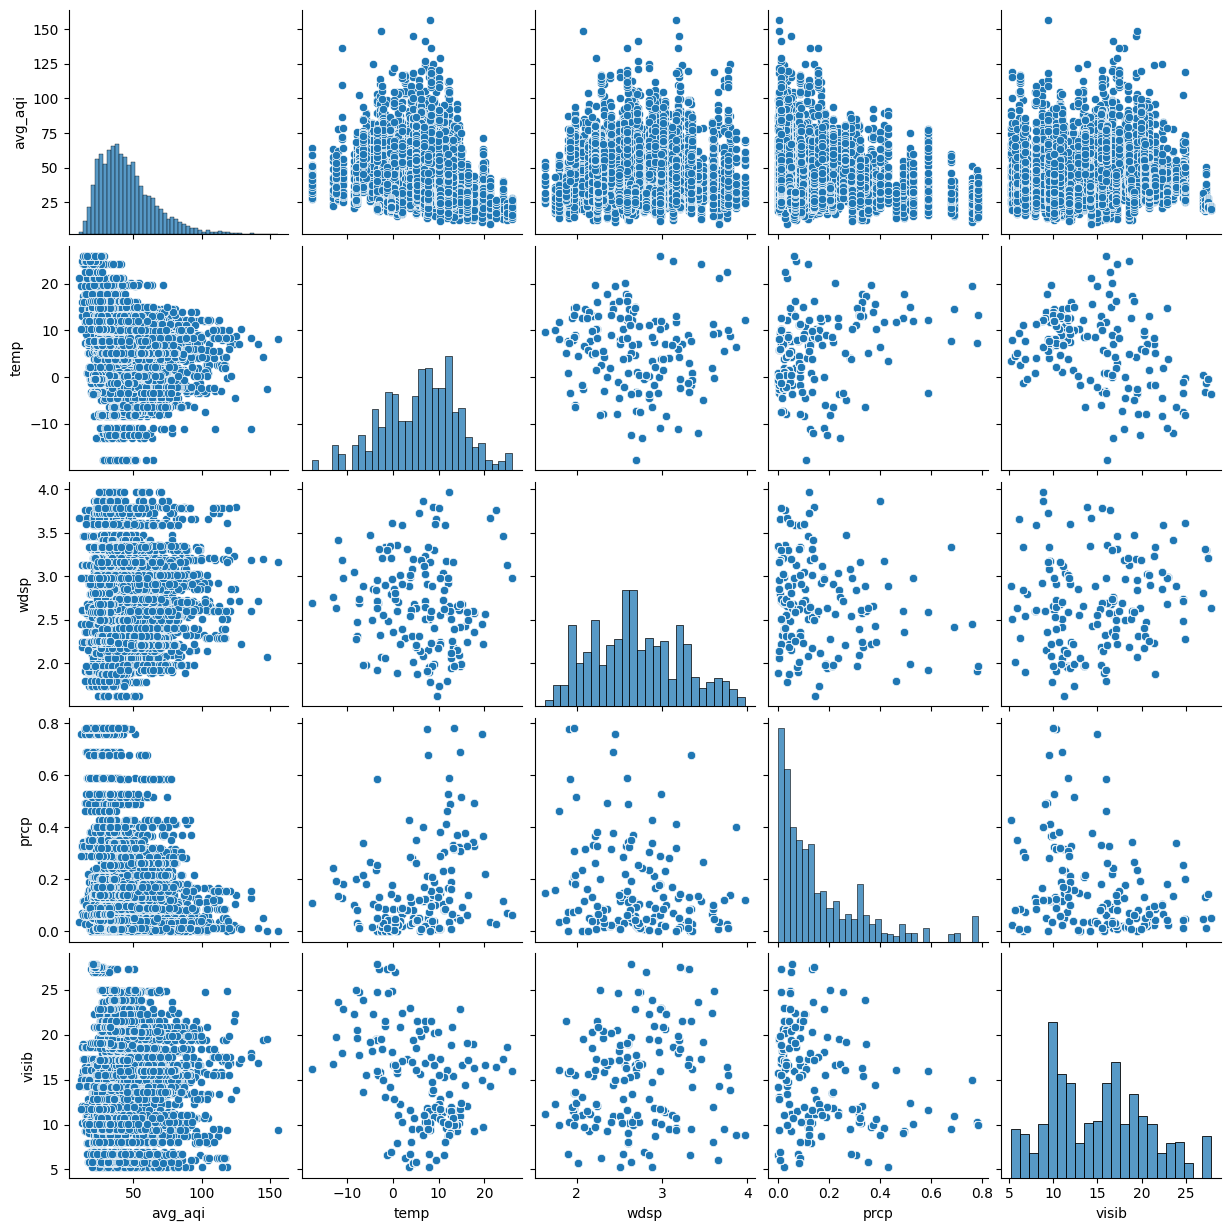

In [ ]:
# Pairplot for pollution vs weather conditions
sns.pairplot(df_pw[["avg_aqi", "temp", "wdsp", "prcp", "visib"]])
plt.show()


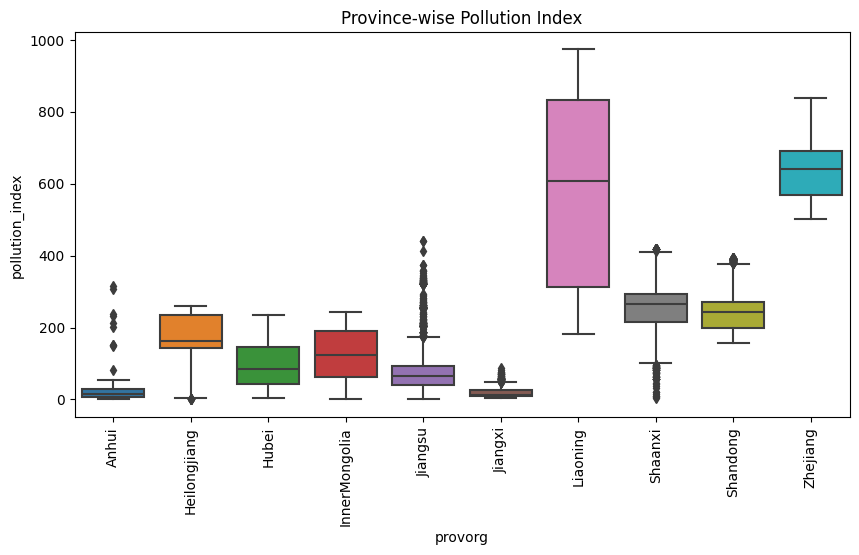

In [ ]:
plt.figure(figsize=(10,5))
sns.boxplot(x="provorg", y="pollution_index", data=df_cems)
plt.xticks(rotation=90)
plt.title("Province-wise Pollution Index")
plt.show()


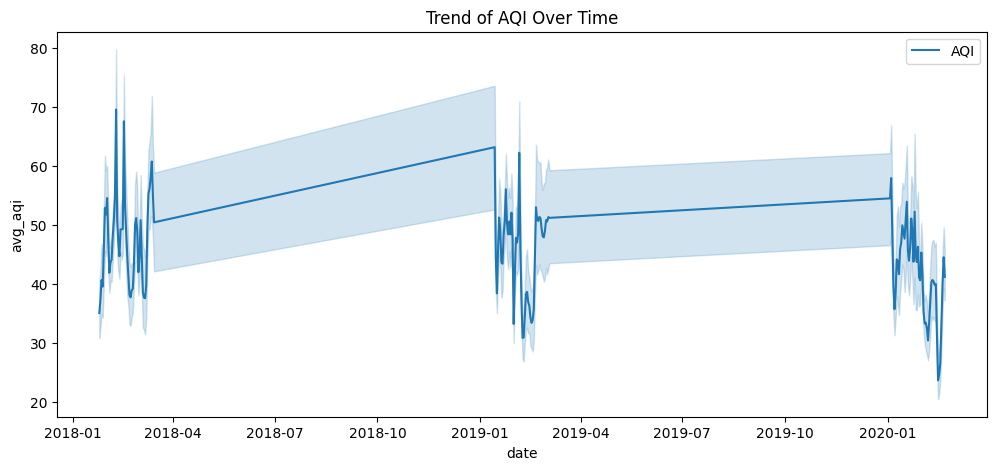

In [ ]:
df_cems["timestamp"] = pd.to_datetime(df_cems["timestamp"])
df_pw["date"] = pd.to_datetime(df_pw["date"])

plt.figure(figsize=(12,5))
sns.lineplot(data=df_pw, x="date", y="avg_aqi", label="AQI")
plt.title("Trend of AQI Over Time")
plt.show()


Correlation Matrix:
           avg_aqi      temp      wdsp      prcp     visib
avg_aqi  1.000000 -0.211076  0.054213 -0.239269 -0.036294
temp    -0.211076  1.000000 -0.083906  0.292974 -0.391578
wdsp     0.054213 -0.083906  1.000000 -0.194432  0.153073
prcp    -0.239269  0.292974 -0.194432  1.000000 -0.314881
visib   -0.036294 -0.391578  0.153073 -0.314881  1.000000


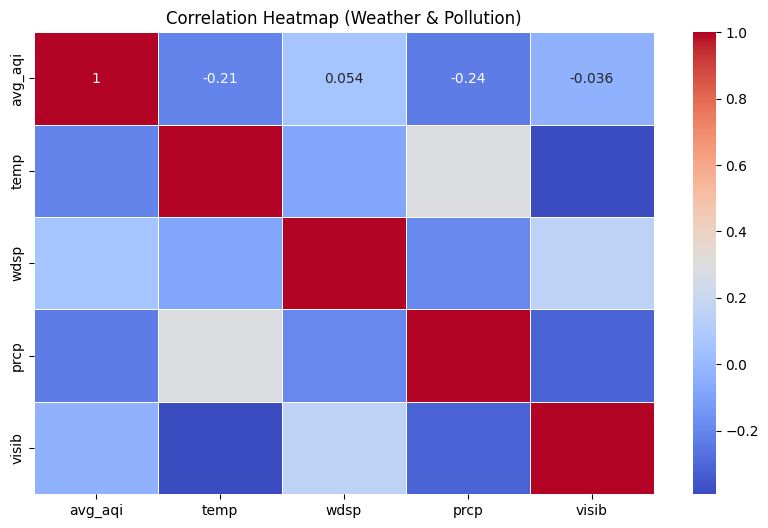

In [ ]:
df_pw = pd.read_csv("cleaned_pollution_weather.csv")

# Convert 'date' column to datetime if it exists
if 'date' in df_pw.columns:
    df_pw['date'] = pd.to_datetime(df_pw['date'])

# Drop non-numeric columns
df_numeric = df_pw.select_dtypes(include=["number"])

# Drop columns that have constant values
df_numeric = df_numeric.loc[:, df_numeric.nunique() > 1]

# Drop rows with missing values
df_numeric = df_numeric.dropna()

# Compute correlation
corr_matrix = df_numeric.corr()

# Check if correlation matrix is valid
print("Correlation Matrix:\n", corr_matrix)

# Plot heatmap
plt.figure(figsize=(10,6))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", linewidths=0.5)
plt.title("Correlation Heatmap (Weather & Pollution)")
plt.show()


In [ ]:
print(df_cems["timestamp"].dtype)  # Should be datetime64
print(df_pw["date"].dtype)         # Should be datetime64


datetime64[ns]
datetime64[ns]


In [ ]:
df_cems["timestamp"] = df_cems["timestamp"].dt.date
df_pw["date"] = df_pw["date"].dt.date


In [ ]:
df_combined = df_cems.merge(df_pw, left_on=["provorg", "timestamp"], right_on=["provorg", "date"], how="left")


In [ ]:
print(df_cems["timestamp"].isna().sum())  # If > 0, fix it
print(df_pw["date"].isna().sum())        # If > 0, fix it


0
0


In [ ]:

# Merge the datasets
df_combined = df_cems.merge(df_pw, left_on=["provorg", "timestamp"], right_on=["provorg", "date"], how="left")

# Display results
print(df_combined.info())  # Check if rows exist
df_combined.head()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 188073 entries, 0 to 188072
Data columns (total 25 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   firm_name           188073 non-null  object 
 1   pollutant_particle  188073 non-null  object 
 2   time_particle       188073 non-null  float64
 3   concentration       188073 non-null  float64
 4   provorg             188073 non-null  object 
 5   dow                 188073 non-null  float64
 6   proven              188073 non-null  object 
 7   timestamp           188073 non-null  object 
 8   time_nox            188073 non-null  float64
 9   year                188073 non-null  float64
 10  nfirms              188073 non-null  int64  
 11  pollutant_nox       188073 non-null  object 
 12  provid              188073 non-null  float64
 13  time                188073 non-null  float64
 14  year_so2            188073 non-null  float64
 15  nfirms_so2          188073 non-nul

,firm_name,pollutant_particle,time_particle,concentration,provorg,dow,proven,timestamp,time_nox,year,...,nfirms_so2,pollutant,provid_so2,pollution_index,date,avg_aqi,temp,wdsp,prcp,visib
0,安徽郎溪南方水泥有限公司,Particle,-12.0,7.762000,Anhui,3.0,HubeiNeighbor,1959-01-22,-12.0,2019.0,...,22,SO2,1.0,44.762000,NaN,NaN,NaN,NaN,NaN,NaN
1,安徽郎溪南方水泥有限公司,Particle,-11.0,7.439913,Anhui,4.0,HubeiNeighbor,1959-01-23,-11.0,2019.0,...,20,SO2,1.0,41.439913,NaN,NaN,NaN,NaN,NaN,NaN
2,安徽郎溪南方水泥有限公司,Particle,-10.0,7.495250,Anhui,5.0,HubeiNeighbor,1959-01-24,-10.0,2019.0,...,21,SO2,1.0,43.495250,NaN,NaN,NaN,NaN,NaN,NaN
3,安徽郎溪南方水泥有限公司,Particle,-9.0,7.600667,Anhui,6.0,HubeiNeighbor,1959-01-25,-9.0,2019.0,...,20,SO2,1.0,41.600667,NaN,NaN,NaN,NaN,NaN,NaN
4,安徽郎溪南方水泥有限公司,Particle,-8.0,7.589958,Anhui,0.0,HubeiNeighbor,1959-01-26,-8.0,2019.0,...,26,SO2,1.0,53.589958,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
print(df_combined.isna().sum())


firm_name                  0
pollutant_particle         0
time_particle              0
concentration              0
provorg                    0
dow                        0
proven                     0
timestamp                  0
time_nox                   0
year                       0
nfirms                     0
pollutant_nox              0
provid                     0
time                       0
year_so2                   0
nfirms_so2                 0
pollutant                  0
provid_so2                 0
pollution_index            0
date                  188073
avg_aqi               188073
temp                  188073
wdsp                  188073
prcp                  188073
visib                 188073
dtype: int64


In [ ]:
df_cems["provorg"] = df_cems["provorg"].str.lower().str.strip()
df_pw["provorg"] = df_pw["provorg"].str.lower().str.strip()


In [ ]:
df_cems["timestamp"] = pd.to_datetime(df_cems["timestamp"])
df_pw["date"] = pd.to_datetime(df_pw["date"])


In [ ]:
print(df_cems["timestamp"].min(), df_cems["timestamp"].max())
print(df_pw["date"].min(), df_pw["date"].max())


1959-01-13 00:00:00 1960-02-20 00:00:00
2018-01-25 00:00:00 2020-02-21 00:00:00


EDA FOR POLLUTION DATASET 

In [31]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [34]:
df_p = pd.read_csv('cleaned_cems.csv')

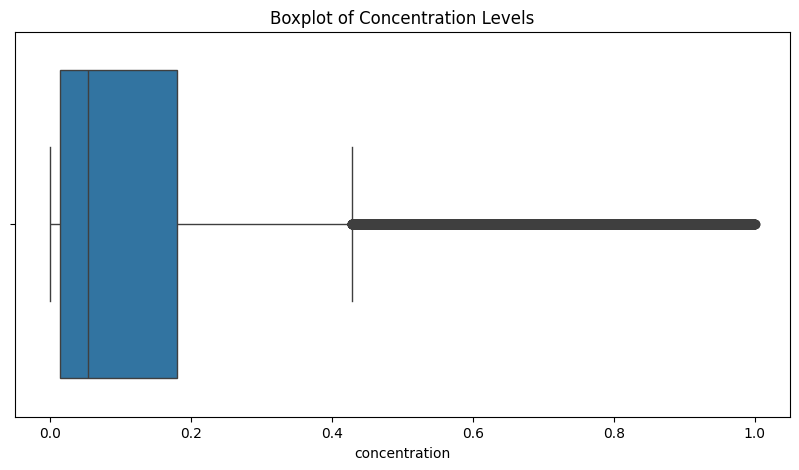

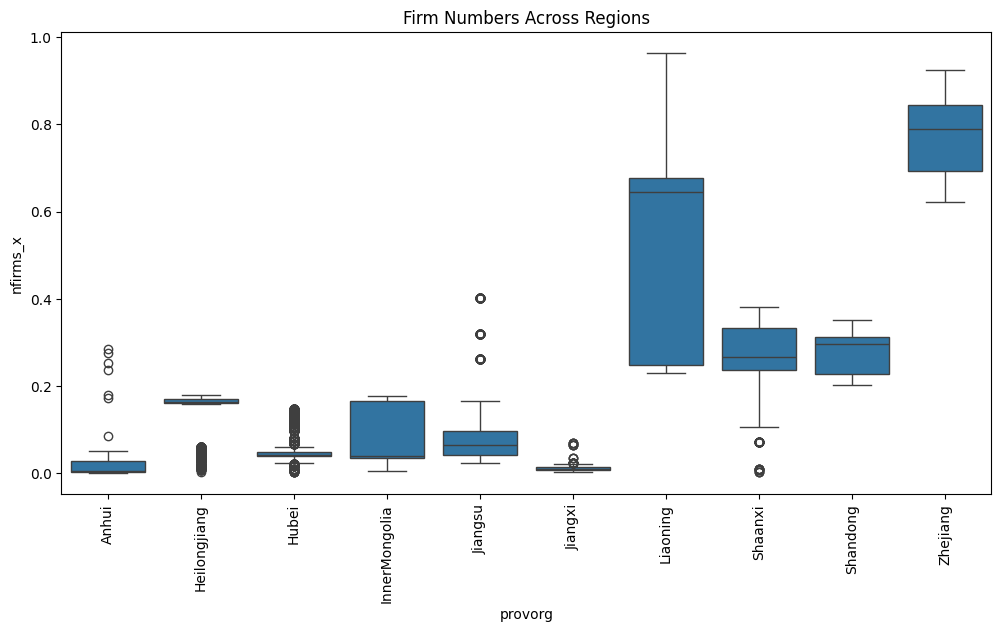

In [35]:
# OUTLIERS DETECTION
plt.figure(figsize=(10, 5))
sns.boxplot(x=df_p['concentration'])
plt.title("Boxplot of Concentration Levels")
plt.show()

plt.figure(figsize=(12, 6))
sns.boxplot(x="provorg", y="nfirms_x", data=df_p)
plt.xticks(rotation=90)
plt.title("Firm Numbers Across Regions")
plt.show()


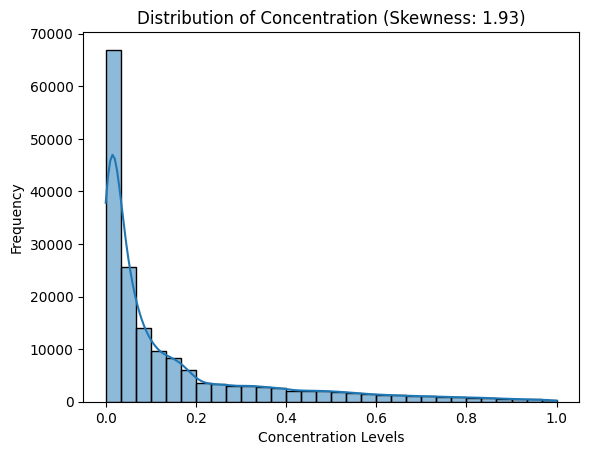

In [36]:
#Skewness & Bimodal Distributions
from scipy.stats import skew

skewness_value = skew(df_p['concentration'].dropna())

sns.histplot(df_p['concentration'], kde=True, bins=30)
plt.title(f"Distribution of Concentration (Skewness: {skewness_value:.2f})")
plt.xlabel("Concentration Levels")
plt.ylabel("Frequency")
plt.show()



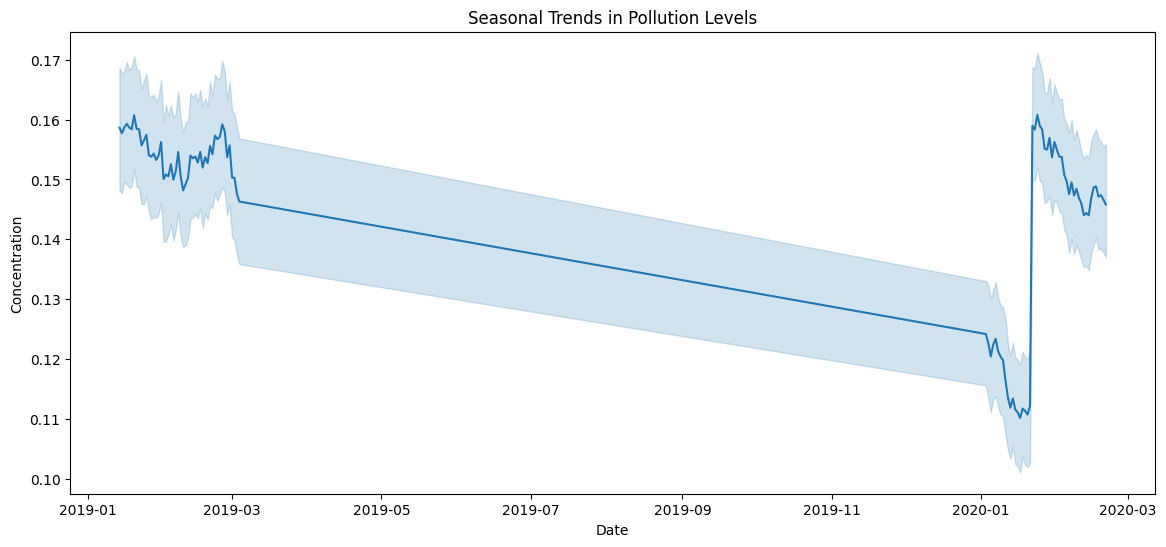

In [37]:
#   Time Series 

df_p['date'] = pd.to_datetime(df_p['date'])

plt.figure(figsize=(14, 6))
sns.lineplot(x='date', y='concentration', data=df_p)
plt.title("Seasonal Trends in Pollution Levels")
plt.xlabel("Date")
plt.ylabel("Concentration")
plt.show()


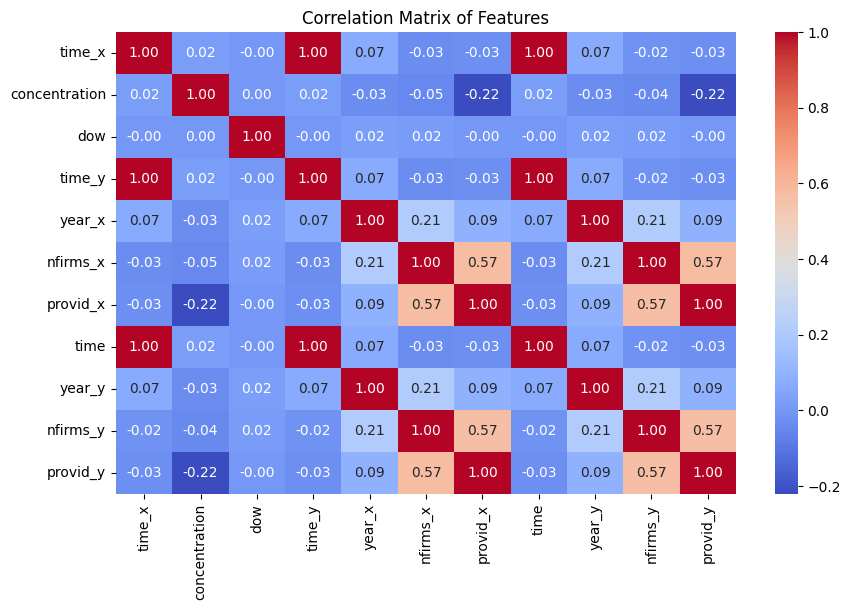

In [38]:
#CORRELATION
plt.figure(figsize=(10, 6))
sns.heatmap(df_p.corr(numeric_only=True), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix of Features")
plt.show()


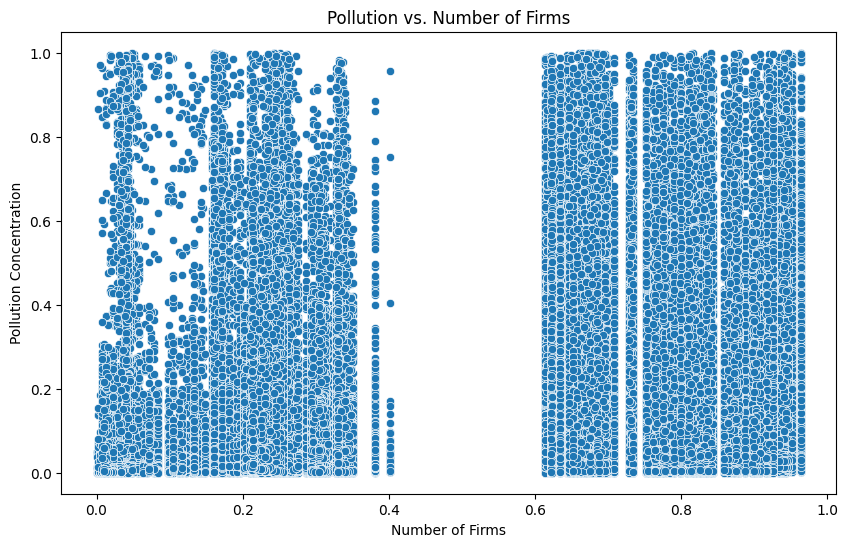

In [39]:
#Pollution Concentration 

plt.figure(figsize=(10, 6))
sns.scatterplot(x=df_p['nfirms_x'], y=df_p['concentration'])
plt.title("Pollution vs. Number of Firms")
plt.xlabel("Number of Firms")
plt.ylabel("Pollution Concentration")
plt.show()


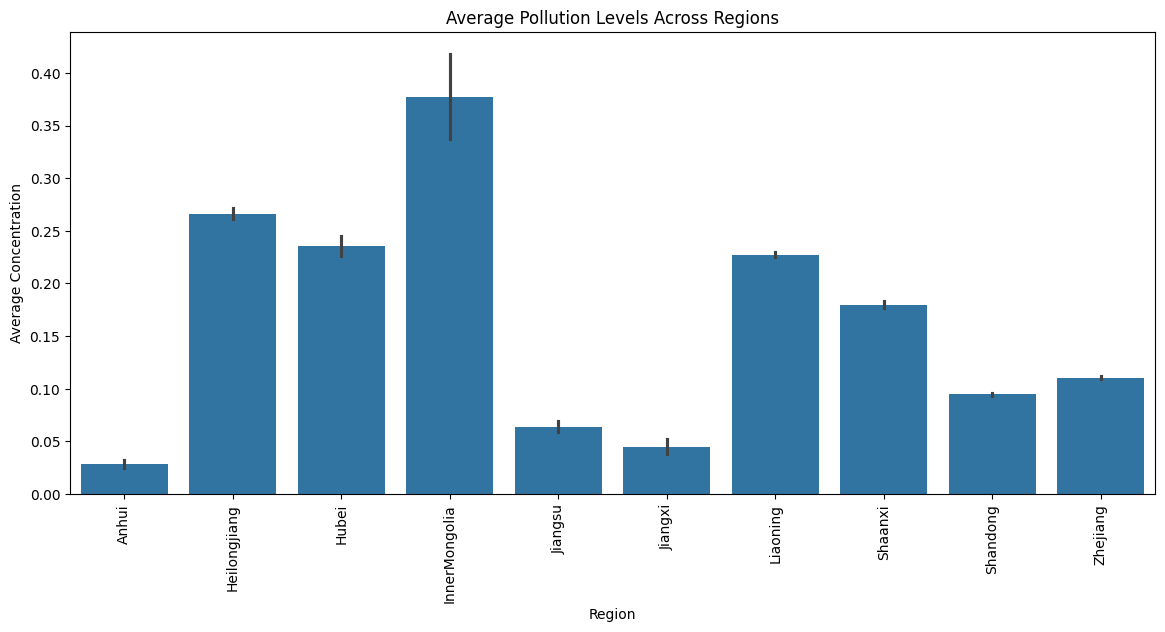

In [40]:
#Pollution across Regions
import numpy as np
plt.figure(figsize=(14, 6))
sns.barplot(x='provorg', y='concentration', data=df_p, estimator=np.mean)
plt.xticks(rotation=90)
plt.title("Average Pollution Levels Across Regions")
plt.xlabel("Region")
plt.ylabel("Average Concentration")
plt.show()

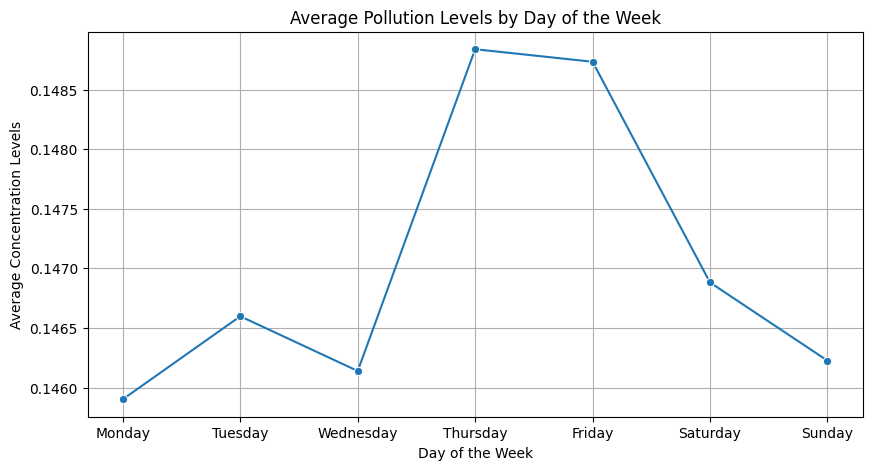

In [45]:
# Day Wise analysis of pollution 
avg_pollution = df_p.groupby('dow')['concentration'].mean()

plt.figure(figsize=(10, 5))
sns.lineplot(x=avg_pollution.index, y=avg_pollution.values, marker='o', linestyle='-')
plt.xlabel("Day of the Week")
plt.ylabel("Average Concentration Levels")
plt.title("Average Pollution Levels by Day of the Week")
plt.xticks(ticks=range(7), labels=["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"])
plt.grid(True)
plt.show()


EDA OF POLLUTION AND AIR QUALITY

In [47]:
dpw = pd.read_csv("C:\\Users\\hp\\OneDrive\\Desktop\\China-Air-pollution-Analysis\\China-Air-pollution-Analysis\\cleaned_pollution_weather.csv")

In [48]:
dpw.columns

Index(['date', 'provorg', 'avg_aqi', 'temp', 'wdsp', 'prcp', 'visib'], dtype='object')

In [49]:
dpw.head()

,date,provorg,avg_aqi,temp,wdsp,prcp,visib
0,2018-01-25,Anhui,30.621572,4.10034,3.085879,0.28359,9.486073
1,2018-01-26,Anhui,34.467580,4.10034,3.085879,0.28359,9.486073
2,2018-01-27,Anhui,34.258030,4.10034,3.085879,0.28359,9.486073
3,2018-01-28,Anhui,56.709930,4.10034,3.085879,0.28359,9.486073
4,2018-01-29,Anhui,87.794530,4.10034,3.085879,0.28359,9.486073


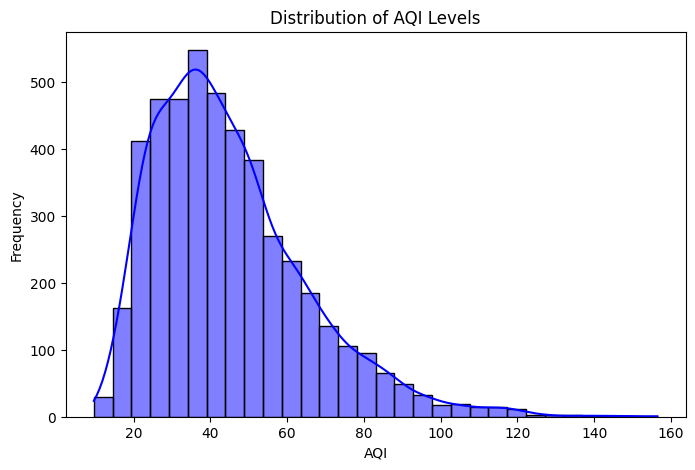

In [55]:
#Air Quality distrubition
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 5))
sns.histplot(dpw["avg_aqi"], bins=30, kde=True, color="blue")
plt.xlabel("AQI")
plt.ylabel("Frequency")
plt.title("Distribution of AQI Levels")
plt.show()


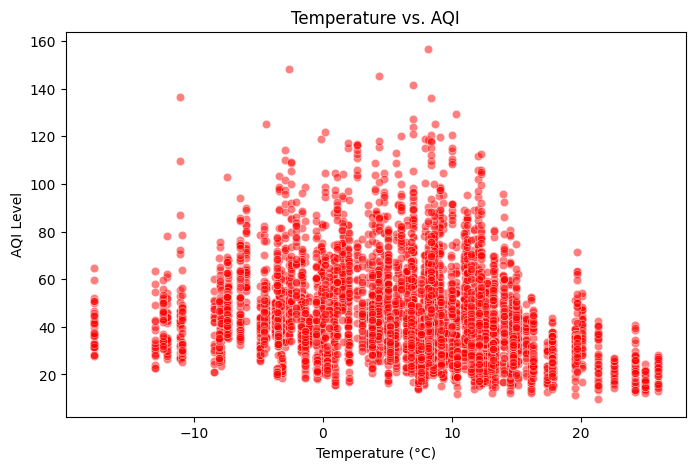

In [53]:
#Temperature vs AQI

plt.figure(figsize=(8, 5))
sns.scatterplot(x=dpw["temp"], y=dpw["avg_aqi"], alpha=0.5, color="red")
plt.xlabel("Temperature (°C)")
plt.ylabel("AQI Level")
plt.title("Temperature vs. AQI")
plt.show()


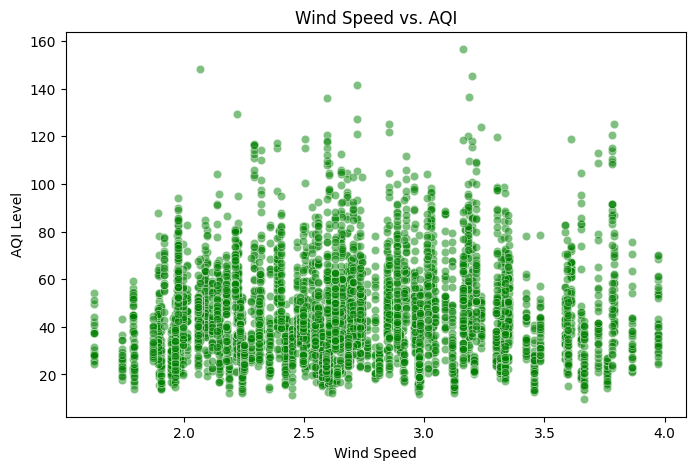

In [57]:
#Windspeed vs AQI
plt.figure(figsize=(8, 5))
sns.scatterplot(x=dpw["wdsp"], y=dpw["avg_aqi"], alpha=0.5, color="green")
plt.xlabel("Wind Speed")
plt.ylabel("AQI Level")
plt.title("Wind Speed vs. AQI")
plt.show()


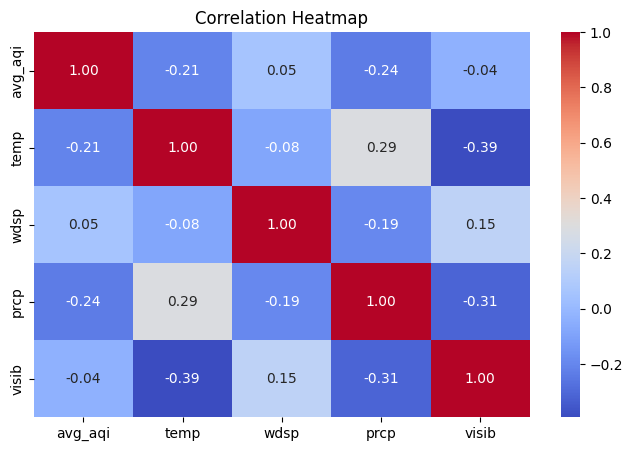

In [61]:
dpw["date"] = pd.to_datetime(dpw["date"])
numeric_df = dpw.select_dtypes(include=["number"])
correlation_matrix = numeric_df.corr()
plt.figure(figsize=(8, 5))
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()